# 05 - Data-only phi validation (LD2 vs CxC)

This notebook validates raw data-only $\phi_h$ distributions in fixed $(Q^2, x_B, z_h)$ bins, using:

- raw $\phi_h \in [0,180]$ (no folding to $|\phi|$),
- SIDIS cuts,
- fit model: $N(\phi)=A+B\cos\phi+C\cos2\phi$.


In [8]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True


In [9]:
# Input parquet patterns (ifarm paths)
LD2_GLOB = "/volatile/clas12/suman/00_RGD_Analysis/data/experimental/parquet/LD2/018420/*.parquet"
CXC_GLOB = "/volatile/clas12/suman/00_RGD_Analysis/data/experimental/parquet/CxC/018454/*.parquet"

# EG2-like validation bins for panel plots
Q2_BINS = [1.0, 2.5, 8.0]       # 2 bins
XB_BINS = [0.1, 0.3, 0.75]      # 2 bins
ZH_BINS = [0.3, 0.45, 0.6, 0.75]# 3 bins

# 48 bins (7.5 deg), or choose your binning
PHI_EDGES = np.linspace(0.0, 360.0, 49) 
PHI_CENTS = 0.5 * (PHI_EDGES[:-1] + PHI_EDGES[1:])


In [10]:
def load_data(pattern):
    files = sorted(glob.glob(pattern))
    if not files:
        raise RuntimeError(f"No parquet files matched: {pattern}")
    df = pd.concat(
        [pd.read_parquet(f, columns=["w_pip", "Q2", "W", "y", "xB", "zh", "pT2", "phi_h"]) for f in files],
        ignore_index=True,
    )
    # SIDIS pion selection
    df = df[df["w_pip"] == 1].copy()
    df = df[
        (df["Q2"] >= 1.0) & (df["W"] >= 2.0) &
        (df["y"] >= 0.25) & (df["y"] <= 0.85) &
        (df["zh"] >= 0.3) & (df["zh"] <= 0.75) &
        (df["pT2"] <= 1.5)
    ]
    # Raw phi in [0,180] only (no abs-folding)
    df = df[(df["phi_h"] >= 0.0) & (df["phi_h"] <= 360.0)]
    return df.dropna(subset=["Q2", "xB", "zh", "phi_h"])

def fit_abc(phi_deg, y):
    # Weighted linear least squares for A + B cos(phi) + C cos(2phi)
    phi = np.radians(phi_deg)
    x = np.column_stack([np.ones_like(phi), np.cos(phi), np.cos(2.0 * phi)])
    w = 1.0 / np.sqrt(np.maximum(y, 1.0))
    xw = x * w[:, None]
    yw = y * w
    beta, *_ = np.linalg.lstsq(xw, yw, rcond=None)
    return beta  # A, B, C


In [11]:
ld2 = load_data(LD2_GLOB)
cxc = load_data(CXC_GLOB)
print(f"LD2 rows after cuts: {len(ld2):,}")
print(f"CxC rows after cuts: {len(cxc):,}")


LD2 rows after cuts: 119,776
CxC rows after cuts: 71,560


In [12]:
def panel_plot(df, target):
    nrows = (len(Q2_BINS) - 1) * (len(XB_BINS) - 1)
    ncols = len(ZH_BINS) - 1
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.3, nrows * 2.9), sharex=True)
    axes = np.array(axes).reshape(nrows, ncols)
    phi_fine = np.linspace(0, 360, 800)

    panel = 0
    for iq2 in range(len(Q2_BINS) - 1):
        q2lo, q2hi = Q2_BINS[iq2], Q2_BINS[iq2 + 1]
        for ixb in range(len(XB_BINS) - 1):
            xblo, xbhi = XB_BINS[ixb], XB_BINS[ixb + 1]
            row = panel
            panel += 1

            for izh in range(len(ZH_BINS) - 1):
                zhlo, zhhi = ZH_BINS[izh], ZH_BINS[izh + 1]
                ax = axes[row, izh]

                sel = df[
                    (df["Q2"] >= q2lo) & (df["Q2"] < q2hi) &
                    (df["xB"] >= xblo) & (df["xB"] < xbhi) &
                    (df["zh"] >= zhlo) & (df["zh"] < zhhi)
                ]["phi_h"].to_numpy()

                counts, _ = np.histogram(sel, bins=PHI_EDGES)
                yerr = np.sqrt(np.maximum(counts, 1))
                ax.errorbar(PHI_CENTS, counts, yerr=yerr, fmt='o', color='black', ms=3, lw=1, label='data')

                if counts.sum() >= 30 and np.count_nonzero(counts) >= 8:
                    A, B, C = fit_abc(PHI_CENTS, counts)
                    fit = A + B*np.cos(np.radians(phi_fine)) + C*np.cos(2*np.radians(phi_fine))
                    ax.plot(phi_fine, fit, color='red', lw=1.5, label='fit')
                    Ac = B / A if abs(A) > 1e-12 else np.nan
                    Acc = C / A if abs(A) > 1e-12 else np.nan
                    ax.text(0.03, 0.93, f"Ac={Ac:.2f}, Acc={Acc:.2f}", transform=ax.transAxes, fontsize=7, va='top')

                ax.set_title(f"z[{zhlo:.2f},{zhhi:.2f}]  Q²[{q2lo:.1f},{q2hi:.1f}]  xB[{xblo:.2f},{xbhi:.2f}]", fontsize=7)
                ax.set_xlim(0, 360)
                ax.set_xticks([0, 60, 120, 180, 240, 300, 360])
                ax.tick_params(labelsize=7)
                if izh == 0:
                    ax.set_ylabel("Counts", fontsize=8)
                if row == nrows - 1:
                    ax.set_xlabel(r"$\phi$ [deg]", fontsize=8)

    handles, labels = axes[0, 0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper right', fontsize=8)
    fig.suptitle(f"{target}: raw data-only $\\phi_h$ in fixed $(Q^2, x_B, z_h)$ bins", fontsize=11, y=0.995)
    plt.tight_layout()
    plt.show()


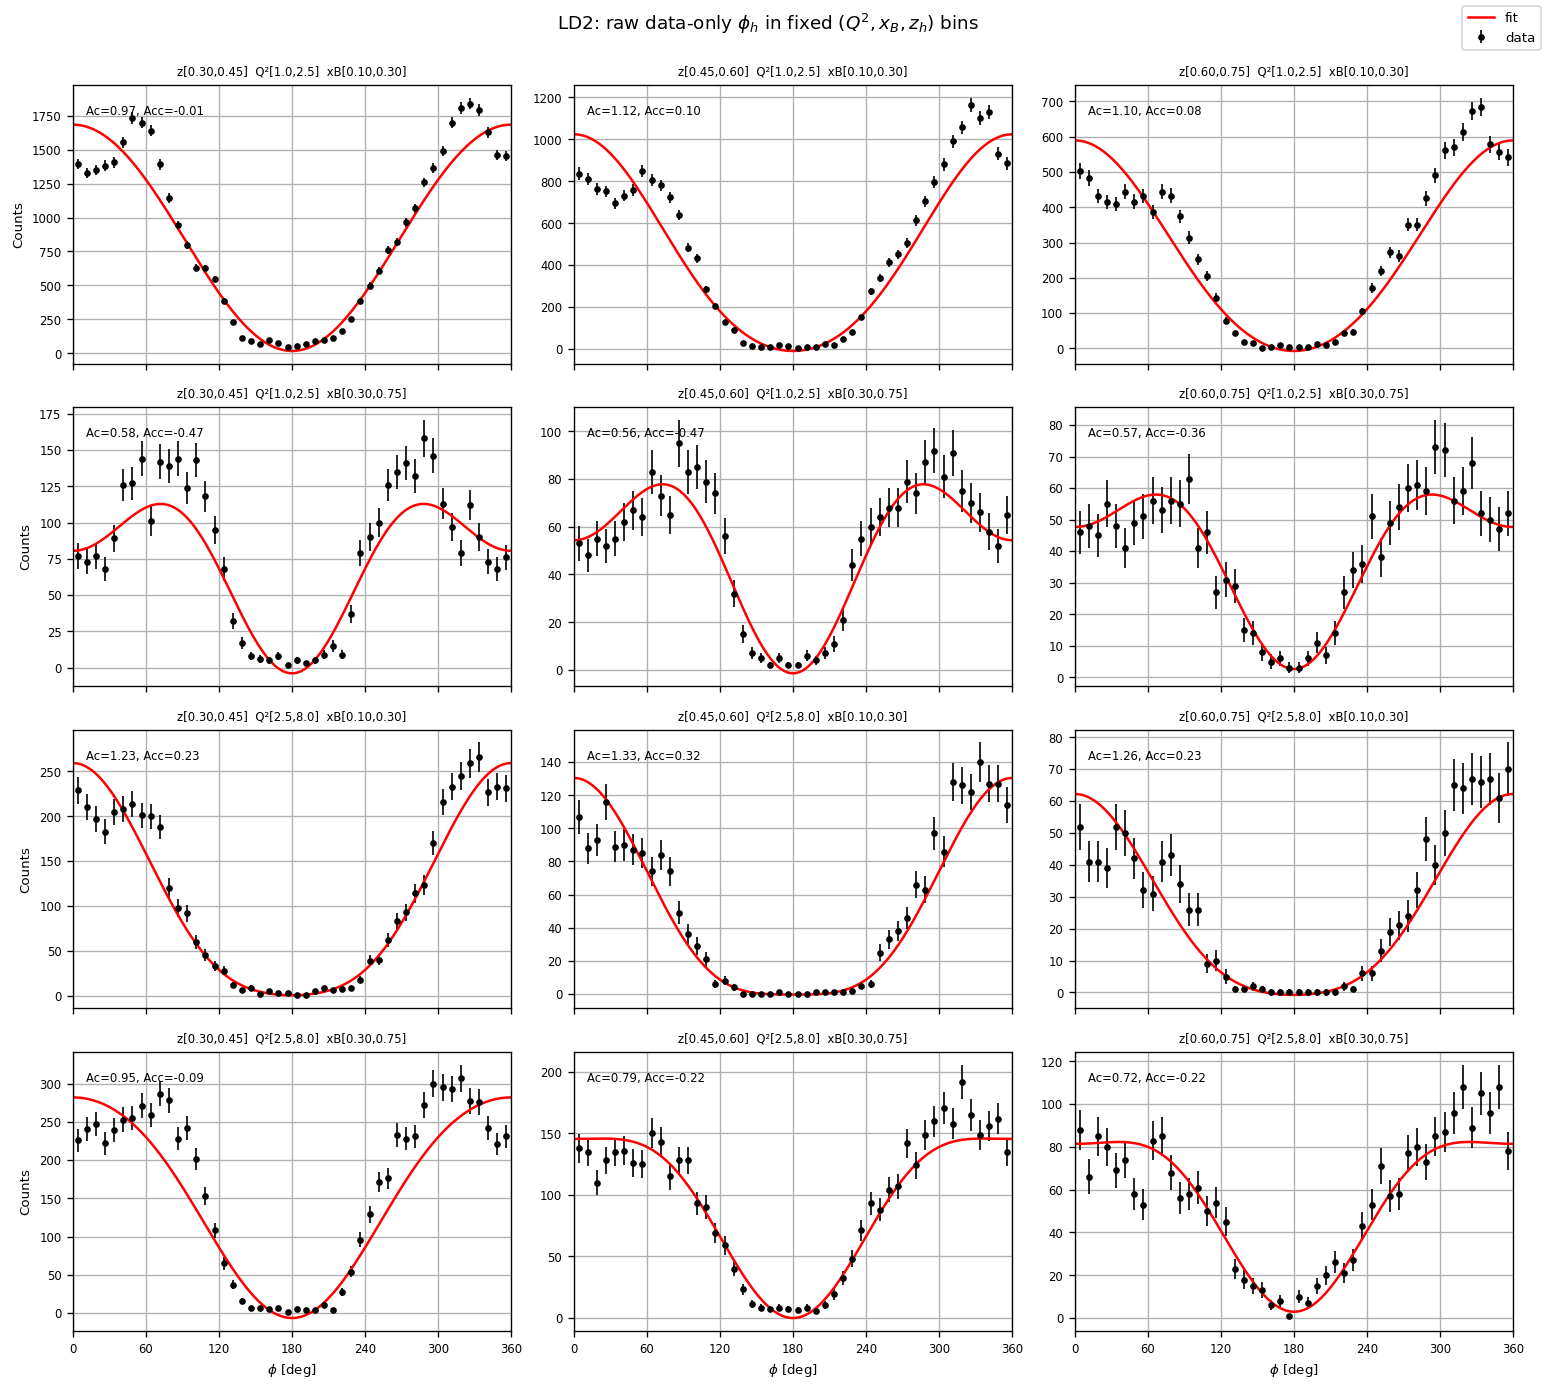

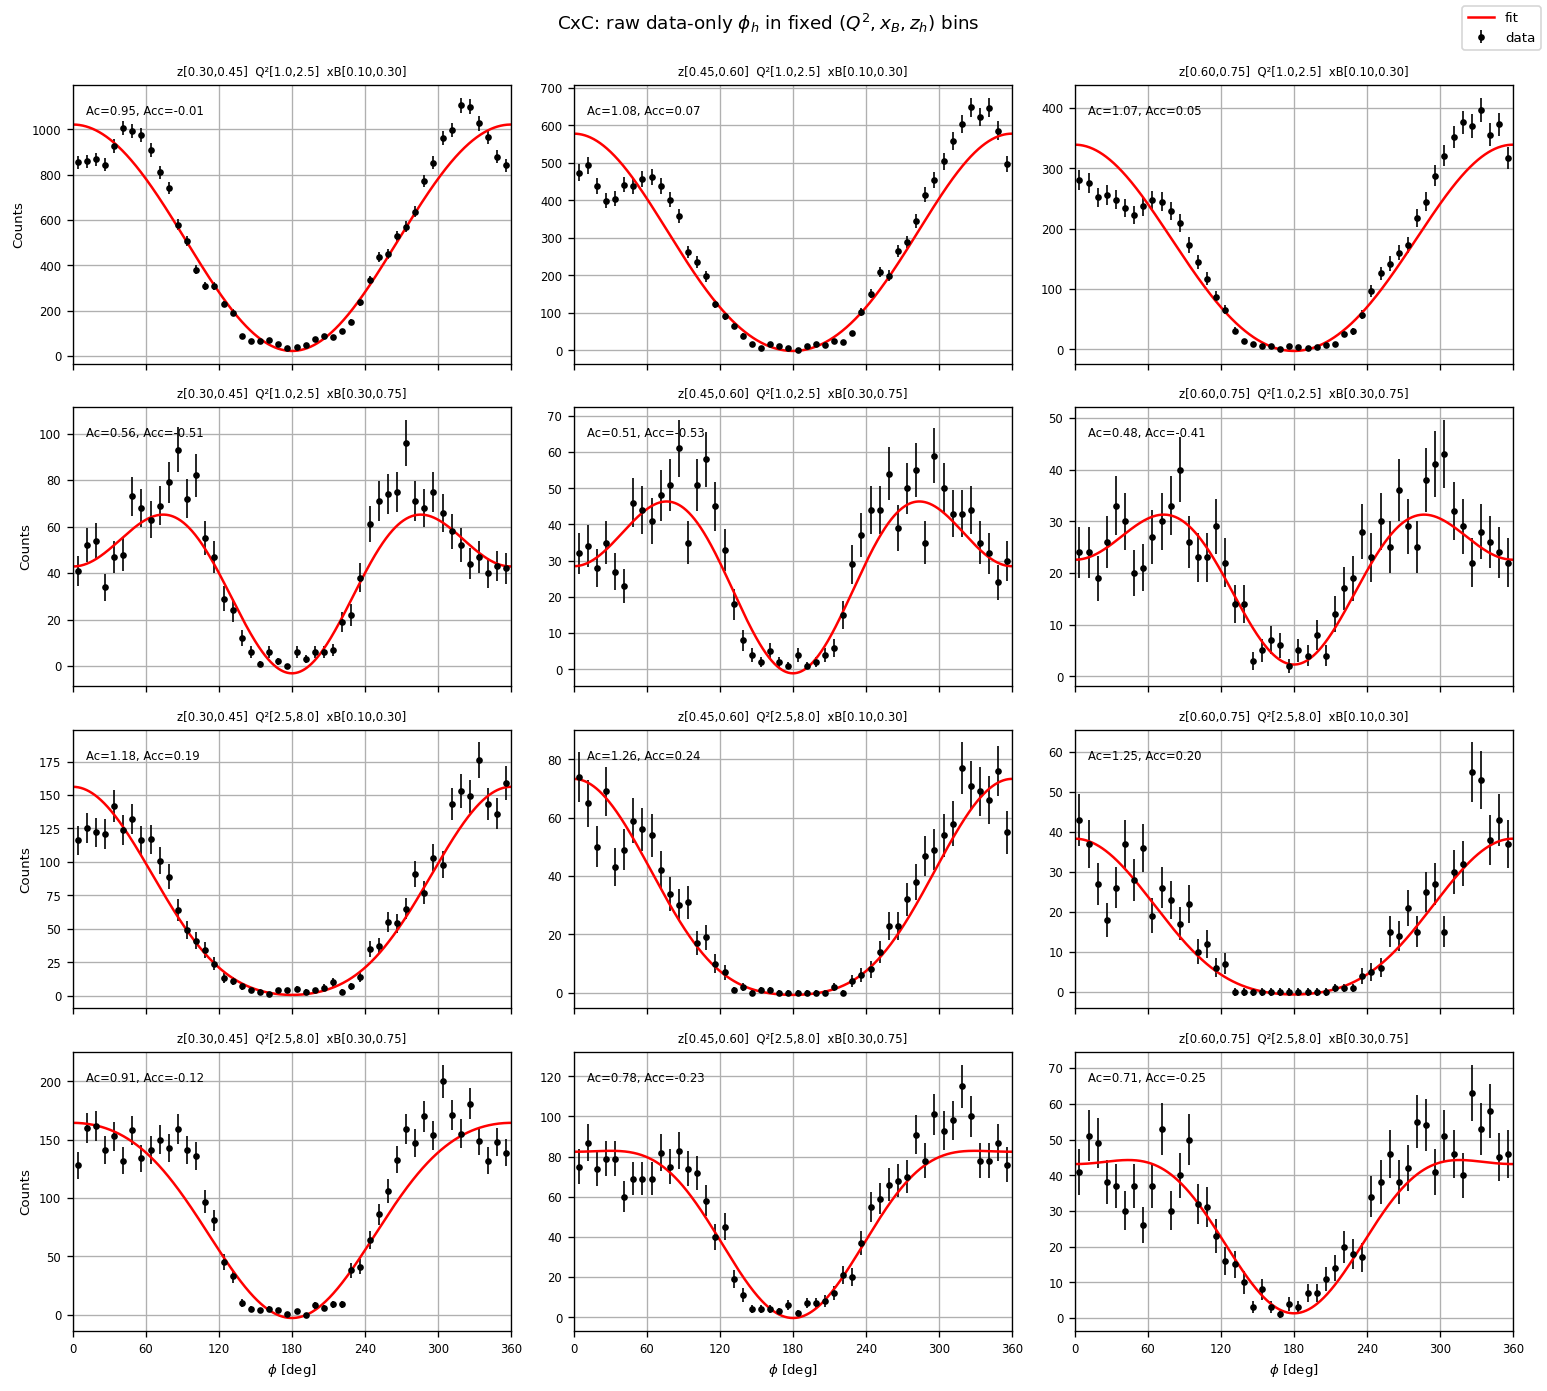

In [13]:
panel_plot(ld2, "LD2")
panel_plot(cxc, "CxC")


Files: 33
Pions after cuts: 119,776


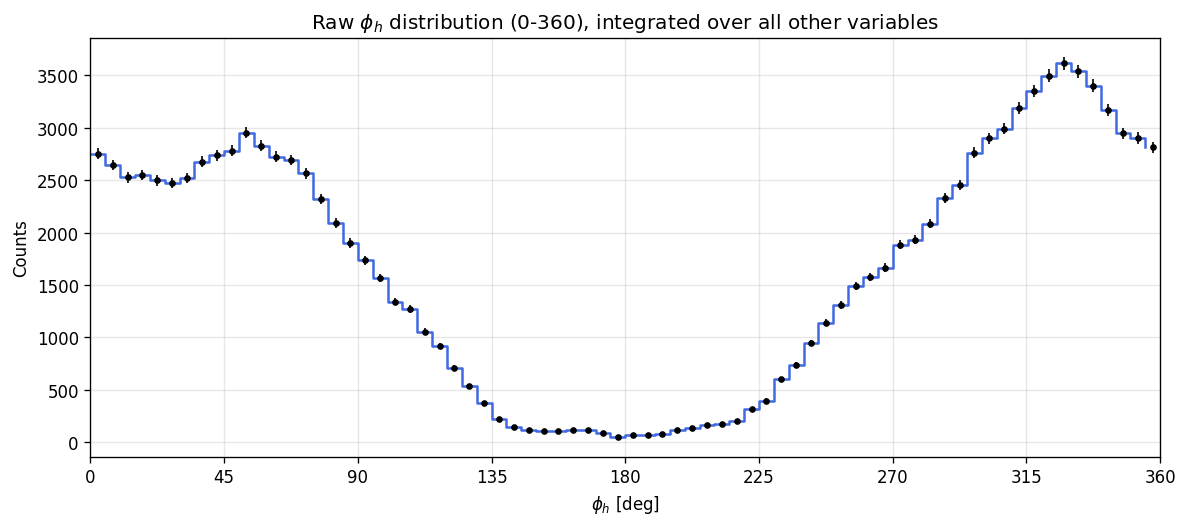

In [14]:
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- choose target parquet glob ----
PARQUET_GLOB = "/volatile/clas12/suman/00_RGD_Analysis/data/experimental/parquet/LD2/018420/*.parquet"
# PARQUET_GLOB = "/volatile/clas12/suman/00_RGD_Analysis/data/experimental/parquet/CxC/018454/*.parquet"

# ---- load only needed columns ----
files = sorted(glob.glob(PARQUET_GLOB))
if not files:
    raise RuntimeError(f"No files matched: {PARQUET_GLOB}")

df = pd.concat(
    [pd.read_parquet(f, columns=["w_pip", "Q2", "W", "y", "zh", "pT2", "phi_h"]) for f in files],
    ignore_index=True,
)

# ---- SIDIS pion selection (raw data) ----
df = df[df["w_pip"] == 1].copy()
df = df[
    (df["Q2"] >= 1.0) & (df["W"] >= 2.0) &
    (df["y"] >= 0.25) & (df["y"] <= 0.85) &
    (df["zh"] >= 0.3) & (df["zh"] <= 0.75) &
    (df["pT2"] <= 1.5)
].dropna(subset=["phi_h"])

# keep raw phi_h in [0, 360]
phi = df["phi_h"].to_numpy()
phi = phi[(phi >= 0.0) & (phi <= 360.0)]

print(f"Files: {len(files)}")
print(f"Pions after cuts: {len(phi):,}")

# ---- plot raw phi (0-360), integrated over all other variables ----
bins = np.linspace(0, 360, 73)  # 5-degree bins
counts, edges = np.histogram(phi, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
yerr = np.sqrt(np.maximum(counts, 1))

plt.figure(figsize=(10, 4.5))
plt.errorbar(centers, counts, yerr=yerr, fmt="o", ms=3, lw=1, color="black")
plt.step(edges[:-1], counts, where="post", color="royalblue", lw=1.5)
plt.xlim(0, 360)
plt.xticks(np.arange(0, 361, 45))
plt.xlabel(r"$\phi_h$ [deg]")
plt.ylabel("Counts")
plt.title(r"Raw $\phi_h$ distribution (0-360), integrated over all other variables")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()